In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import re
import os

sns.set_style("whitegrid")
os.makedirs("results", exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


In [ ]:
df = pd.read_csv("../data/clinvar_result.txt", sep="\t")

cols_to_remove = [
    "Somatic clinical impact",
    "Somatic clinical impact date last evaluated",
    "Somatic clinical impact review status",
    "Oncogenicity classification",
    "Oncogenicity date last evaluated",
    "Oncogenicity review status",
    "Unnamed: 24",
]
df = df.drop(columns=cols_to_remove)

print(f"Loaded {len(df)} OTOF variants from ClinVar.")

Loaded 2432 OTOF variants from ClinVar.


In [ ]:
def extract_aa_position(name):
    if pd.isna(name):
        return np.nan
    # Look for patterns like "p.Arg963Ter" or "p.Met1858Val" or "p.Gly783AlafsTer17"
    match = re.search(r"p\.[A-Z][a-z]{2}(\d+)", str(name))
    if match:
        return int(match.group(1))
    return np.nan

df["aa_position"] = df["Name"].apply(extract_aa_position)

# How many variants have an extractable amino acid position?
mapped = df["aa_position"].notna().sum()
print(f"Variants with extractable amino acid position: {mapped} / {len(df)}")
print(f"\nRange of positions: {int(df['aa_position'].min())} to {int(df['aa_position'].max())}")

Variants with extractable amino acid position: 1600 / 2432

Range of positions: 2 to 1997


In [ ]:
# Otoferlin protein domains (UniProt P52787, canonical isoform, 1997 aa)
# Domain boundaries from UniProt + literature on C2 domain architecture
PROTEIN_LENGTH = 1997

domains = [
    {"name": "C2A", "start": 1,    "end": 122,  "color": "#4C72B0"},
    {"name": "C2B", "start": 360,  "end": 480,  "color": "#55A868"},
    {"name": "C2C", "start": 481,  "end": 596,  "color": "#C44E52"},
    {"name": "C2D", "start": 940,  "end": 1054, "color": "#8172B2"},
    {"name": "C2E", "start": 1158, "end": 1273, "color": "#CCB974"},
    {"name": "C2F", "start": 1481, "end": 1597, "color": "#64B5CD"},
    {"name": "TM",  "start": 1942, "end": 1973, "color": "#777777"},
]

# Assign each variant to its domain (or "Linker" if outside)
def assign_domain(pos):
    if pd.isna(pos):
        return None
    for d in domains:
        if d["start"] <= pos <= d["end"]:
            return d["name"]
    return "Linker"

df["domain"] = df["aa_position"].apply(assign_domain)

# Count variants per domain
domain_counts = df["domain"].value_counts()
print("Variants per domain:")
print(domain_counts)

Variants per domain:
domain
Linker    1020
C2E        103
C2C         99
C2A         92
C2D         88
C2B         88
C2F         85
TM          25
Name: count, dtype: int64


In [ ]:
pathogenic_classes = ["Pathogenic", "Likely pathogenic", "Pathogenic/Likely pathogenic"]
benign_classes = ["Benign", "Likely benign", "Benign/Likely benign"]
vus_classes = ["Uncertain significance", "Conflicting classifications of pathogenicity"]

def simplify_classification(cls):
    if cls in pathogenic_classes:
        return "Pathogenic"
    if cls in benign_classes:
        return "Benign"
    if cls in vus_classes:
        return "Uncertain"
    return "Other"

df["simplified_class"] = df["Germline classification"].apply(simplify_classification)

# Crosstab domain vs simplified class
domain_class_table = pd.crosstab(df["domain"], df["simplified_class"])
print("Variants by domain and classification:")
print(domain_class_table)

Variants by domain and classification:
simplified_class  Benign  Other  Pathogenic  Uncertain
domain                                                
C2A                   42      0           8         42
C2B                   37      3          20         28
C2C                   46      5          18         30
C2D                   38      0          18         32
C2E                   49      0          15         39
C2F                   34      1          15         35
Linker               419     17         158        426
TM                    13      0           3          9


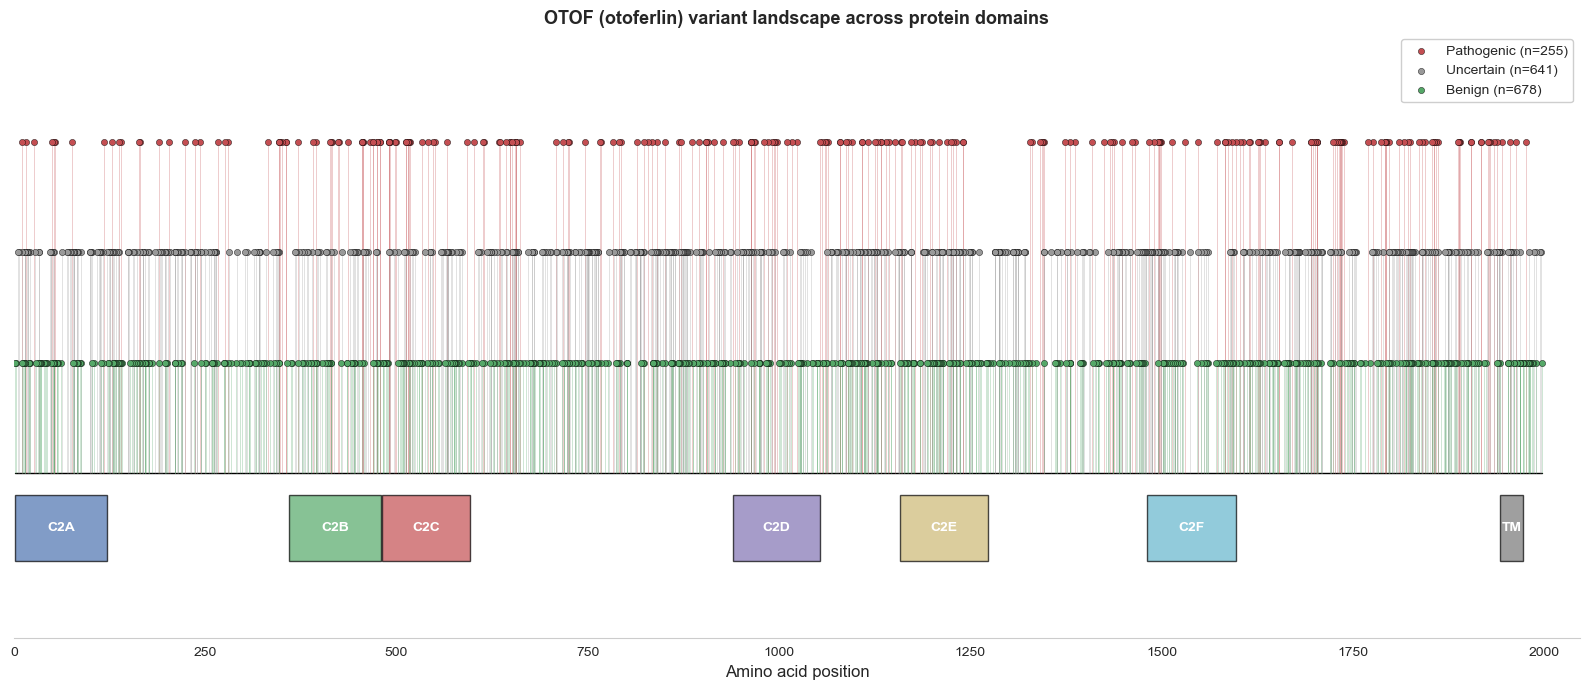

In [ ]:
# Filter to variants with valid position and simplified class
plot_df = df.dropna(subset=["aa_position"]).copy()
plot_df = plot_df[plot_df["simplified_class"].isin(["Pathogenic", "Benign", "Uncertain"])]

# Color map
class_colors = {
    "Pathogenic": "#C44E52",
    "Benign": "#55A868",
    "Uncertain": "#999999",
}

# Set up figure
fig, ax = plt.subplots(figsize=(16, 7))

# Plot domains as colored rectangles at the bottom
domain_y = -0.8
domain_height = 0.6
for d in domains:
    rect = patches.Rectangle(
        (d["start"], domain_y), d["end"] - d["start"], domain_height,
        linewidth=1, edgecolor="black", facecolor=d["color"], alpha=0.7
    )
    ax.add_patch(rect)
    # Label inside the domain
    center = (d["start"] + d["end"]) / 2
    ax.text(center, domain_y + domain_height / 2, d["name"],
            ha="center", va="center", fontsize=10, fontweight="bold", color="white")

# Backbone line (the protein)
ax.plot([1, PROTEIN_LENGTH], [0, 0], color="black", linewidth=1, zorder=1)

# Plot variants as lollipops
# Stack variants by class: pathogenic top, uncertain middle, benign bottom
class_order = ["Pathogenic", "Uncertain", "Benign"]
class_y_offset = {"Pathogenic": 3, "Uncertain": 2, "Benign": 1}

for cls in class_order:
    subset = plot_df[plot_df["simplified_class"] == cls]
    positions = subset["aa_position"].values
    y_value = class_y_offset[cls]
    # Stem
    for pos in positions:
        ax.plot([pos, pos], [0, y_value], color=class_colors[cls], linewidth=0.4, alpha=0.5, zorder=2)
    # Marker (lollipop head)
    ax.scatter(positions, [y_value] * len(positions),
               s=20, color=class_colors[cls], edgecolor="black",
               linewidth=0.3, zorder=3, label=f"{cls} (n={len(positions)})")

# Axes setup
ax.set_xlim(0, PROTEIN_LENGTH + 50)
ax.set_ylim(-1.5, 4)
ax.set_xlabel("Amino acid position", fontsize=12)
ax.set_yticks([])
ax.set_title("OTOF (otoferlin) variant landscape across protein domains", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=10, framealpha=0.95)
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.savefig("../results/otof_lollipop_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Pathogenic density per domain (P/LP per aa)
print("Pathogenic variant density per domain:")
print("=" * 60)

for d in domains:
    domain_name = d["name"]
    domain_length = d["end"] - d["start"] + 1
    n_pathogenic = len(plot_df[(plot_df["domain"] == domain_name) & (plot_df["simplified_class"] == "Pathogenic")])
    density = n_pathogenic / domain_length
    print(f"  {domain_name:6s} ({domain_length:4d} aa): {n_pathogenic:3d} pathogenic --> density = {density:.4f} per aa")

# Linker regions (everything outside domains)
linker_pathogenic = len(plot_df[(plot_df["domain"] == "Linker") & (plot_df["simplified_class"] == "Pathogenic")])
total_domain_aa = sum(d["end"] - d["start"] + 1 for d in domains)
linker_length = PROTEIN_LENGTH - total_domain_aa
linker_density = linker_pathogenic / linker_length
print(f"\n  {'Linker':6s} ({linker_length:4d} aa): {linker_pathogenic:3d} pathogenic --> density = {linker_density:.4f} per aa")

Pathogenic variant density per domain:
  C2A    ( 122 aa):   8 pathogenic --> density = 0.0656 per aa
  C2B    ( 121 aa):  20 pathogenic --> density = 0.1653 per aa
  C2C    ( 116 aa):  18 pathogenic --> density = 0.1552 per aa
  C2D    ( 115 aa):  18 pathogenic --> density = 0.1565 per aa
  C2E    ( 116 aa):  15 pathogenic --> density = 0.1293 per aa
  C2F    ( 117 aa):  15 pathogenic --> density = 0.1282 per aa
  TM     (  32 aa):   3 pathogenic --> density = 0.0938 per aa

  Linker (1258 aa): 158 pathogenic --> density = 0.1256 per aa


## Statistical Analysis — Domain-Level Pathogenic Variant Density

We test whether the observed distribution of pathogenic variants across
C2 domains deviates significantly from the null expectation of uniform
distribution proportional to domain length, using two complementary approaches:
1. Chi-square goodness-of-fit test against the length-proportional null
2. Permutation test (n=10,000) without parametric assumptions

In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Domain definitions (UniProt Q9HC10, 1997 aa)
domains = {
    "C2A": 122, "C2B": 121, "C2C": 116,
    "C2D": 115, "C2E": 116, "C2F": 117, "TM": 32,
}

# Observed P/LP counts per domain (from your domain mapping analysis)
plp_counts = {
    "C2A": 8, "C2B": 20, "C2C": 18,
    "C2D": 18, "C2E": 15, "C2F": 15, "TM": 3,
}

total_plp    = sum(plp_counts.values())
total_length = sum(domains.values())

# Expected under length-proportional null
expected = {d: (domains[d] / total_length) * total_plp for d in domains}

print(f"Total P/LP in named domains : {total_plp}")
print(f"Total named domain length   : {total_length} aa\n")
print(f"{'Domain':6s} {'Length':>7s} {'Observed':>9s} {'Expected':>9s}")
print("-" * 35)
for d in domains:
    print(f"{d:6s} {domains[d]:>7d} {plp_counts[d]:>9d} {expected[d]:>9.1f}")

Total P/LP in named domains : 97
Total named domain length   : 739 aa

Domain  Length  Observed  Expected
-----------------------------------
C2A        122         8      16.0
C2B        121        20      15.9
C2C        116        18      15.2
C2D        115        18      15.1
C2E        116        15      15.2
C2F        117        15      15.4
TM          32         3       4.2


In [ ]:
# Chi-square goodness-of-fit
obs_arr = np.array([plp_counts[d] for d in domains])
exp_arr = np.array([expected[d]   for d in domains])

chi2, pval_chi2 = stats.chisquare(f_obs=obs_arr, f_exp=exp_arr)

print("=" * 55)
print("Chi-square goodness-of-fit")
print(f"  Chi2 = {chi2:.3f}  |  df = {len(domains)-1}  |  p = {pval_chi2:.4f}")
if pval_chi2 < 0.05:
    print("  SIGNIFICANT: domain enrichment is non-random")
else:
    print("  Not significant at alpha = 0.05")
print("=" * 55)

Chi-square goodness-of-fit
  Chi2 = 6.497  |  df = 6  |  p = 0.3699
  Not significant at alpha = 0.05


In [ ]:
# Permutation test (n=10,000)
np.random.seed(42)
N_PERM = 10_000

# Build residue-label array for all named-domain residues
residue_labels = np.repeat(list(domains.keys()),
                           list(domains.values()))

print(f"Permuting {total_plp} P/LP variants over "
      f"{total_length} residues × {N_PERM:,} permutations...")

perm_densities = {d: np.empty(N_PERM) for d in domains}
domain_lengths = np.array([domains[d] for d in domains])
domain_names   = np.array(list(domains.keys()))

for i in range(N_PERM):
    idx = np.random.choice(total_length, size=total_plp, replace=False)
    sampled = residue_labels[idx]
    for j, d in enumerate(domains):
        perm_densities[d][i] = np.sum(sampled == d) / domains[d]

# Results table
print(f"\n{'Domain':6s} {'Length':>7s} {'P/LP':>5s} "
      f"{'Obs dens':>10s} {'Null mean':>10s} {'p-value':>10s} {'Sig':>5s}")
print("-" * 60)

results_rows = []
for d in domains:
    obs_d  = plp_counts[d] / domains[d]
    pval   = float(np.mean(perm_densities[d] >= obs_d))
    sig    = ("***" if pval < 0.001 else
              "**"  if pval < 0.01  else
              "*"   if pval < 0.05  else "n.s.")
    print(f"{d:6s} {domains[d]:>7d} {plp_counts[d]:>5d} "
          f"{obs_d:>10.4f} {perm_densities[d].mean():>10.4f} "
          f"{pval:>10.4f} {sig:>5s}")
    results_rows.append({
        "Domain": d, "Length_aa": domains[d],
        "PLP_count": plp_counts[d], "Obs_density": round(obs_d, 4),
        "Null_mean": round(perm_densities[d].mean(), 4),
        "Null_SD": round(perm_densities[d].std(), 4),
        "p_value": round(pval, 4) if pval > 0 else f"<{1/N_PERM:.4f}",
        "Significance": sig,
    })

import pandas as pd
results_df = pd.DataFrame(results_rows)
results_df.to_csv("../results/domain_permutation_test.csv", index=False)
print("\nSaved: results/domain_permutation_test.csv")
print(f"\nChi-square: chi2={chi2:.3f}, df={len(domains)-1}, p={pval_chi2:.4f}")

Permuting 97 P/LP variants over 739 residues × 10,000 permutations...

Domain  Length  P/LP   Obs dens  Null mean    p-value   Sig
------------------------------------------------------------
C2A        122     8     0.0656     0.1312     0.9955  n.s.
C2B        121    20     0.1653     0.1312     0.1420  n.s.
C2C        116    18     0.1552     0.1315     0.2490  n.s.
C2D        115    18     0.1565     0.1310     0.2276  n.s.
C2E        116    15     0.1293     0.1310     0.5726  n.s.
C2F        117    15     0.1282     0.1315     0.5968  n.s.
TM          32     3     0.0938     0.1316     0.8212  n.s.

Saved: results/domain_permutation_test.csv

Chi-square: chi2=6.497, df=6, p=0.3699


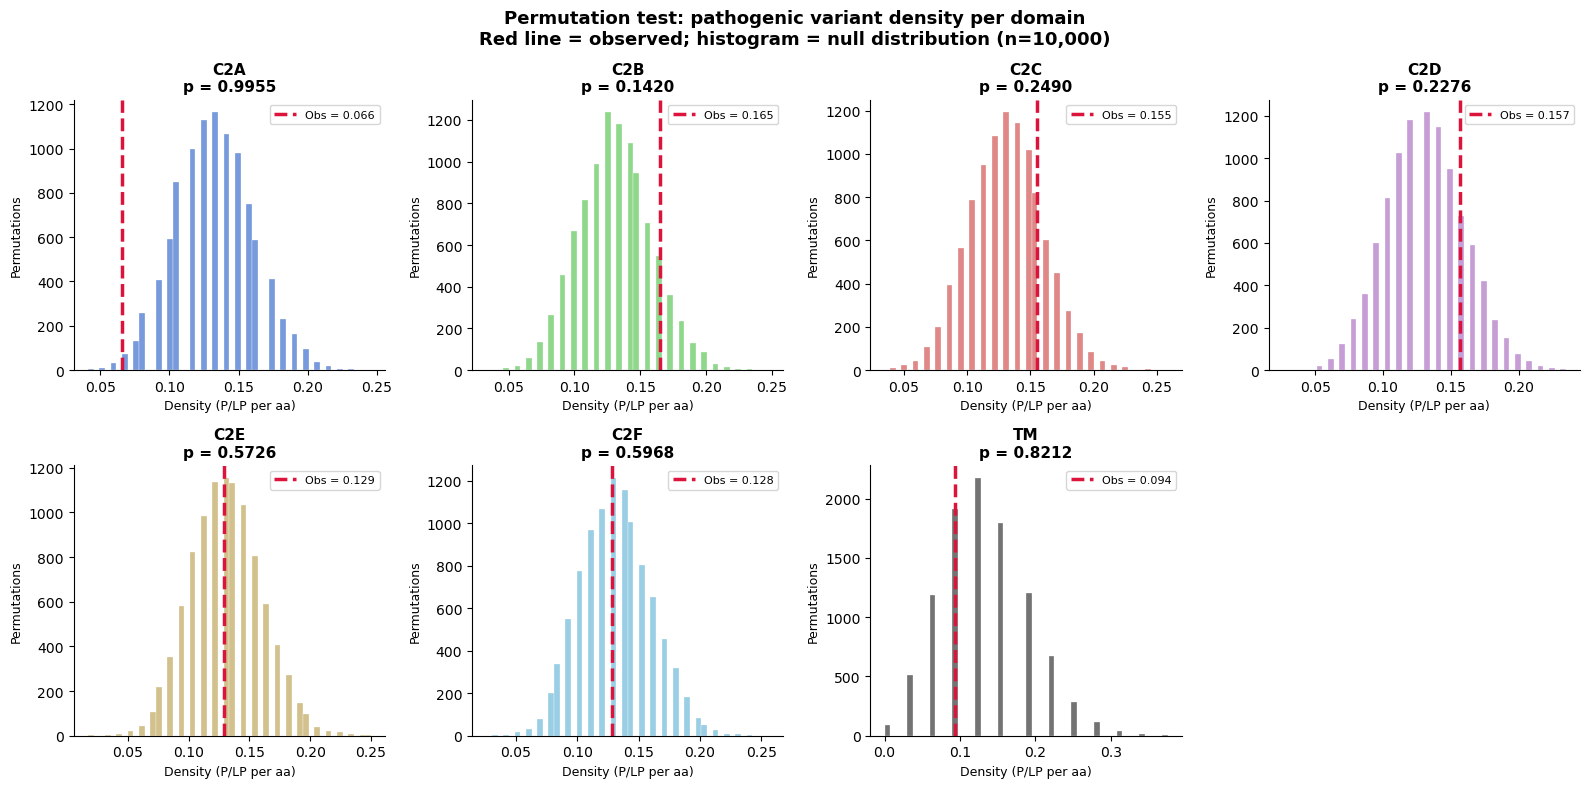

Saved: results/domain_permutation_test.png


In [ ]:
# Figure: permutation distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

domain_colors = {
    "C2A": "#4878d0", "C2B": "#6acc65", "C2C": "#d65f5f",
    "C2D": "#b47cc7", "C2E": "#c4ad66", "C2F": "#77bedb", "TM": "#444444"
}

for i, d in enumerate(domains):
    ax    = axes[i]
    perm  = perm_densities[d]
    obs_d = plp_counts[d] / domains[d]
    pval  = float(np.mean(perm >= obs_d))

    ax.hist(perm, bins=50, color=domain_colors[d],
            alpha=0.75, edgecolor="white", linewidth=0.3)
    ax.axvline(obs_d, color="crimson", linewidth=2.5, linestyle="--",
               label=f"Obs = {obs_d:.3f}")
    pval_label = f"p = {pval:.4f}" if pval > 0 else f"p < {1/N_PERM:.4f}"
    ax.set_title(f"{d}\n{pval_label}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Density (P/LP per aa)", fontsize=9)
    ax.set_ylabel("Permutations", fontsize=9)
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

axes[7].set_visible(False)

fig.suptitle(
    "Permutation test: pathogenic variant density per domain\n"
    "Red line = observed; histogram = null distribution (n=10,000)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("../results/domain_permutation_test.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: results/domain_permutation_test.png")

In [ ]:
# Two-tailed permutation test
# For each domain, test both enrichment and depletion against the null

print(f"{'Domain':6s} {'Obs dens':>10s} {'Null mean':>10s} "
      f"{'p (enrich)':>12s} {'p (deplete)':>12s} {'p (2-tail)':>12s} {'Direction':>10s} {'Sig':>5s}")
print("-" * 80)

results_2tail = []
for d in domains:
    obs_d     = plp_counts[d] / domains[d]
    perm      = perm_densities[d]
    p_enrich  = float(np.mean(perm >= obs_d))
    p_deplete = float(np.mean(perm <= obs_d))
    p_2tail   = 2 * min(p_enrich, p_deplete)
    p_2tail   = min(p_2tail, 1.0)

    if obs_d > perm.mean():
        direction = "enriched"
    else:
        direction = "depleted"

    sig = ("***" if p_2tail < 0.001 else
           "**"  if p_2tail < 0.01  else
           "*"   if p_2tail < 0.05  else "n.s.")

    print(f"{d:6s} {obs_d:>10.4f} {perm.mean():>10.4f} "
          f"{p_enrich:>12.4f} {p_deplete:>12.4f} "
          f"{p_2tail:>12.4f} {direction:>10s} {sig:>5s}")

    results_2tail.append({
        "Domain": d,
        "Length_aa": domains[d],
        "PLP_count": plp_counts[d],
        "Obs_density": round(obs_d, 4),
        "Null_mean": round(float(perm.mean()), 4),
        "p_enrichment": round(p_enrich, 4),
        "p_depletion": round(p_deplete, 4),
        "p_twotail": round(p_2tail, 4),
        "Direction": direction,
        "Significance": sig,
    })

df_2tail = pd.DataFrame(results_2tail)
df_2tail.to_csv("../results/domain_permutation_test_2tail.csv", index=False)
print("\nSaved: results/domain_permutation_test_2tail.csv")
print(f"\nChi-square global test: chi2={chi2:.3f}, df={len(domains)-1}, p={pval_chi2:.4f}")

Domain   Obs dens  Null mean   p (enrich)  p (deplete)   p (2-tail)  Direction   Sig
--------------------------------------------------------------------------------
C2A        0.0656     0.1312       0.9955       0.0116       0.0232   depleted     *
C2B        0.1653     0.1312       0.1420       0.9129       0.2840   enriched  n.s.
C2C        0.1552     0.1315       0.2490       0.8331       0.4980   enriched  n.s.
C2D        0.1565     0.1310       0.2276       0.8449       0.4552   enriched  n.s.
C2E        0.1293     0.1310       0.5726       0.5428       1.0000   depleted  n.s.
C2F        0.1282     0.1315       0.5968       0.5245       1.0000   depleted  n.s.
TM         0.0938     0.1316       0.8212       0.3701       0.7402   depleted  n.s.

Saved: results/domain_permutation_test_2tail.csv

Chi-square global test: chi2=6.497, df=6, p=0.3699


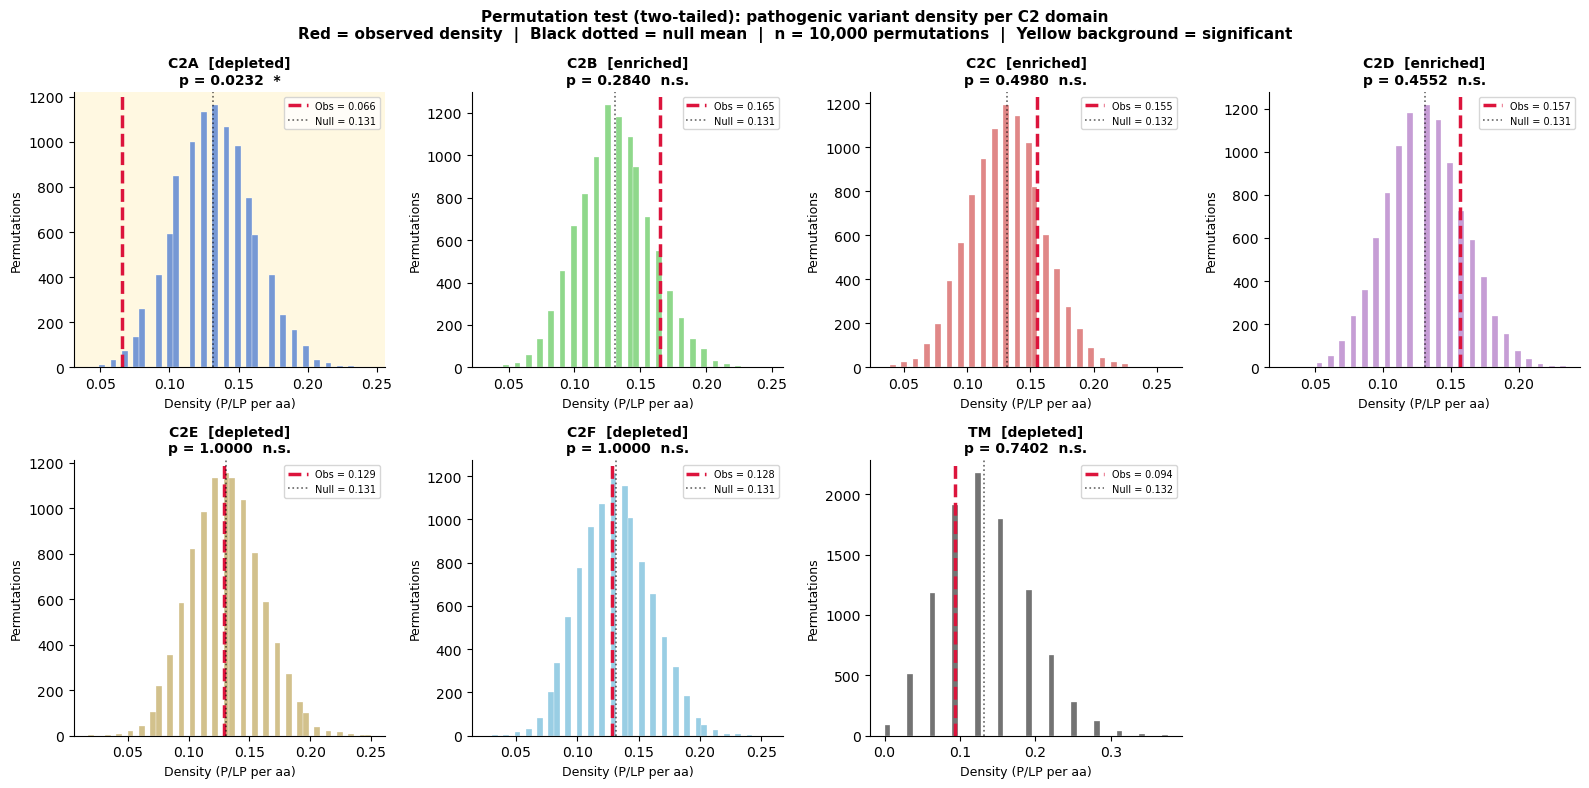

Saved: results/domain_permutation_test_2tail.png


In [ ]:
# Figure: two-tailed permutation test distributions with direction annotation

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

domain_colors = {
    "C2A": "#4878d0", "C2B": "#6acc65", "C2C": "#d65f5f",
    "C2D": "#b47cc7", "C2E": "#c4ad66", "C2F": "#77bedb", "TM": "#444444"
}

for i, row in enumerate(results_2tail):
    d     = row["Domain"]
    ax    = axes[i]
    perm  = perm_densities[d]
    obs_d = row["Obs_density"]
    p2    = row["p_twotail"]
    direc = row["Direction"]
    sig   = row["Significance"]

    ax.hist(perm, bins=50, color=domain_colors[d],
            alpha=0.75, edgecolor="white", linewidth=0.3)
    ax.axvline(obs_d, color="crimson", linewidth=2.5,
               linestyle="--", label=f"Obs = {obs_d:.3f}")
    ax.axvline(float(np.mean(perm)), color="black", linewidth=1.2,
               linestyle=":", alpha=0.6, label=f"Null = {float(np.mean(perm)):.3f}")

    p_label = f"p = {p2:.4f}" if p2 > 0.0001 else "p < 0.0001"
    title   = f"{d}  [{direc}]\n{p_label}  {sig}"
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Density (P/LP per aa)", fontsize=9)
    ax.set_ylabel("Permutations", fontsize=9)
    ax.legend(fontsize=7)
    ax.spines[["top", "right"]].set_visible(False)

    # Highlight significant domains
    if sig != "n.s.":
        ax.patch.set_facecolor("#fff8e1")

axes[7].set_visible(False)

fig.suptitle(
    "Permutation test (two-tailed): pathogenic variant density per C2 domain\n"
    "Red = observed density  |  Black dotted = null mean  |  "
    "n = 10,000 permutations  |  Yellow background = significant",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.savefig("../results/domain_permutation_test_2tail.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: results/domain_permutation_test_2tail.png")

In [ ]:
# Publication-ready summary table
print("=" * 75)
print("Table — Domain-level pathogenic variant density: permutation analysis")
print("=" * 75)
print(f"{'Domain':<8} {'Length':>8} {'P/LP':>6} {'Obs density':>12} "
      f"{'Null mean±SD':>16} {'p (2-tail)':>12} {'':>5}")
print("-" * 75)

for row in results_2tail:
    d      = row["Domain"]
    perm   = perm_densities[d]
    null_str = f"{row['Null_mean']:.3f}±{float(np.std(perm)):.3f}"
    p_str  = f"{row['p_twotail']:.4f}" if row['p_twotail'] > 0.0001 else "<0.0001"
    sig    = row["Significance"]
    marker = " ← significant" if sig != "n.s." else ""
    print(f"{d:<8} {row['Length_aa']:>8} {row['PLP_count']:>6} "
          f"{row['Obs_density']:>12.4f} {null_str:>16} {p_str:>12} {sig:>5}{marker}")

print("-" * 75)
print(f"Chi-square goodness-of-fit: chi2 = {chi2:.3f}, df = {len(domains)-1}, p = {pval_chi2:.4f}")
print(f"Permutation test: n = 10,000, two-tailed, seed = 42")
print(f"Null hypothesis: P/LP variants distributed uniformly proportional to domain length")
print("=" * 75)

Table — Domain-level pathogenic variant density: permutation analysis
Domain     Length   P/LP  Obs density     Null mean±SD   p (2-tail)      
---------------------------------------------------------------------------
C2A           122      8       0.0656      0.131±0.028       0.0232     * ← significant
C2B           121     20       0.1653      0.131±0.028       0.2840  n.s.
C2C           116     18       0.1552      0.132±0.029       0.4980  n.s.
C2D           115     18       0.1565      0.131±0.029       0.4552  n.s.
C2E           116     15       0.1293      0.131±0.029       1.0000  n.s.
C2F           117     15       0.1282      0.132±0.029       1.0000  n.s.
TM             32      3       0.0938      0.132±0.058       0.7402  n.s.
---------------------------------------------------------------------------
Chi-square goodness-of-fit: chi2 = 6.497, df = 6, p = 0.3699
Permutation test: n = 10,000, two-tailed, seed = 42
Null hypothesis: P/LP variants distributed uniformly propor